<a href="https://colab.research.google.com/github/AkshayMendiratta2006/IncodeVision-ML-Internship/blob/main/Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IncodeVision ML Internship - Task 01
**Project:** Data Cleaning and Visualization

**Description:**
This notebook performs data cleaning and exploratory data analysis (EDA) on an open-source dataset using Python, pandas, matplotlib, and seaborn. It handles missing values, fixes data types, and visualizes trends using histograms, bar charts, box plots, and correlation heatmaps.

**Dataset:**
The dataset used for this project is the **TMDb 5000 Movies Dataset**.
* You can download the dataset from Kaggle here: [TMDb 5000 Movie Dataset on Kaggle](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata)

In [59]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
# Load the dataset
df = pd.read_csv('tmdb_5000_movies.csv')
display(df.head())
print('\n---Dataset Info---')
df.info()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124



---Dataset Info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  s

In [61]:
# Data Cleaning
columns_to_drop = ['homepage', 'tagline']
df_cleaned = df.drop(columns=columns_to_drop)
df_cleaned = df_cleaned.dropna(subset=['overview', 'release_date', 'runtime'])
df_cleaned['release_date'] = pd.to_datetime(df_cleaned['release_date'])
df_cleaned = df_cleaned.drop_duplicates()

print('\n---Cleaned Dataset Info---')
df_cleaned.info()


---Cleaned Dataset Info---
<class 'pandas.core.frame.DataFrame'>
Index: 4799 entries, 0 to 4802
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   budget                4799 non-null   int64         
 1   genres                4799 non-null   object        
 2   id                    4799 non-null   int64         
 3   keywords              4799 non-null   object        
 4   original_language     4799 non-null   object        
 5   original_title        4799 non-null   object        
 6   overview              4799 non-null   object        
 7   popularity            4799 non-null   float64       
 8   production_companies  4799 non-null   object        
 9   production_countries  4799 non-null   object        
 10  release_date          4799 non-null   datetime64[ns]
 11  revenue               4799 non-null   int64         
 12  runtime               4799 non-null   float64       


In [62]:
# Checking if there are any rows with zero budget or zero revenue movie.
zero_budget =(df_cleaned['budget'] == 0).sum()
zero_revenue =(df_cleaned['revenue'] == 0).sum()
print(f"\nMovies with 0 budget: {zero_budget}")
print(f"Movies with 0 revenue: {zero_revenue}")


Movies with 0 budget: 1036
Movies with 0 revenue: 1423


In [63]:
# Creating a new DataFrame for financial analysis, filtering out 0 budget and 0 revenue
df_finances = df_cleaned[(df_cleaned['budget'] > 0) & (df_cleaned['revenue'] > 0)].copy()
df_finances['release_yaer'] = df_finances['release_date'].dt.year
print(f"Movies remaining for financial analysis: {len(df_finances)}\n")
display(df_finances[['budget', 'revenue', 'vote_average']].describe())

Movies remaining for financial analysis: 3229



,budget,revenue,vote_average
count,3.229000e+03,3.229000e+03,3229.000000
mean,4.065444e+07,1.212430e+08,6.309353
std,4.439674e+07,1.863029e+08,0.873891
min,1.000000e+00,5.000000e+00,0.000000
25%,1.050000e+07,1.700000e+07,5.800000
50%,2.500000e+07,5.518472e+07,6.300000
75%,5.500000e+07,1.462920e+08,6.900000
max,3.800000e+08,2.787965e+09,8.500000


/tmp/ipykernel_1142/1250090.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='revenue', y='title', data=top_10_revenue, palette='viridis')


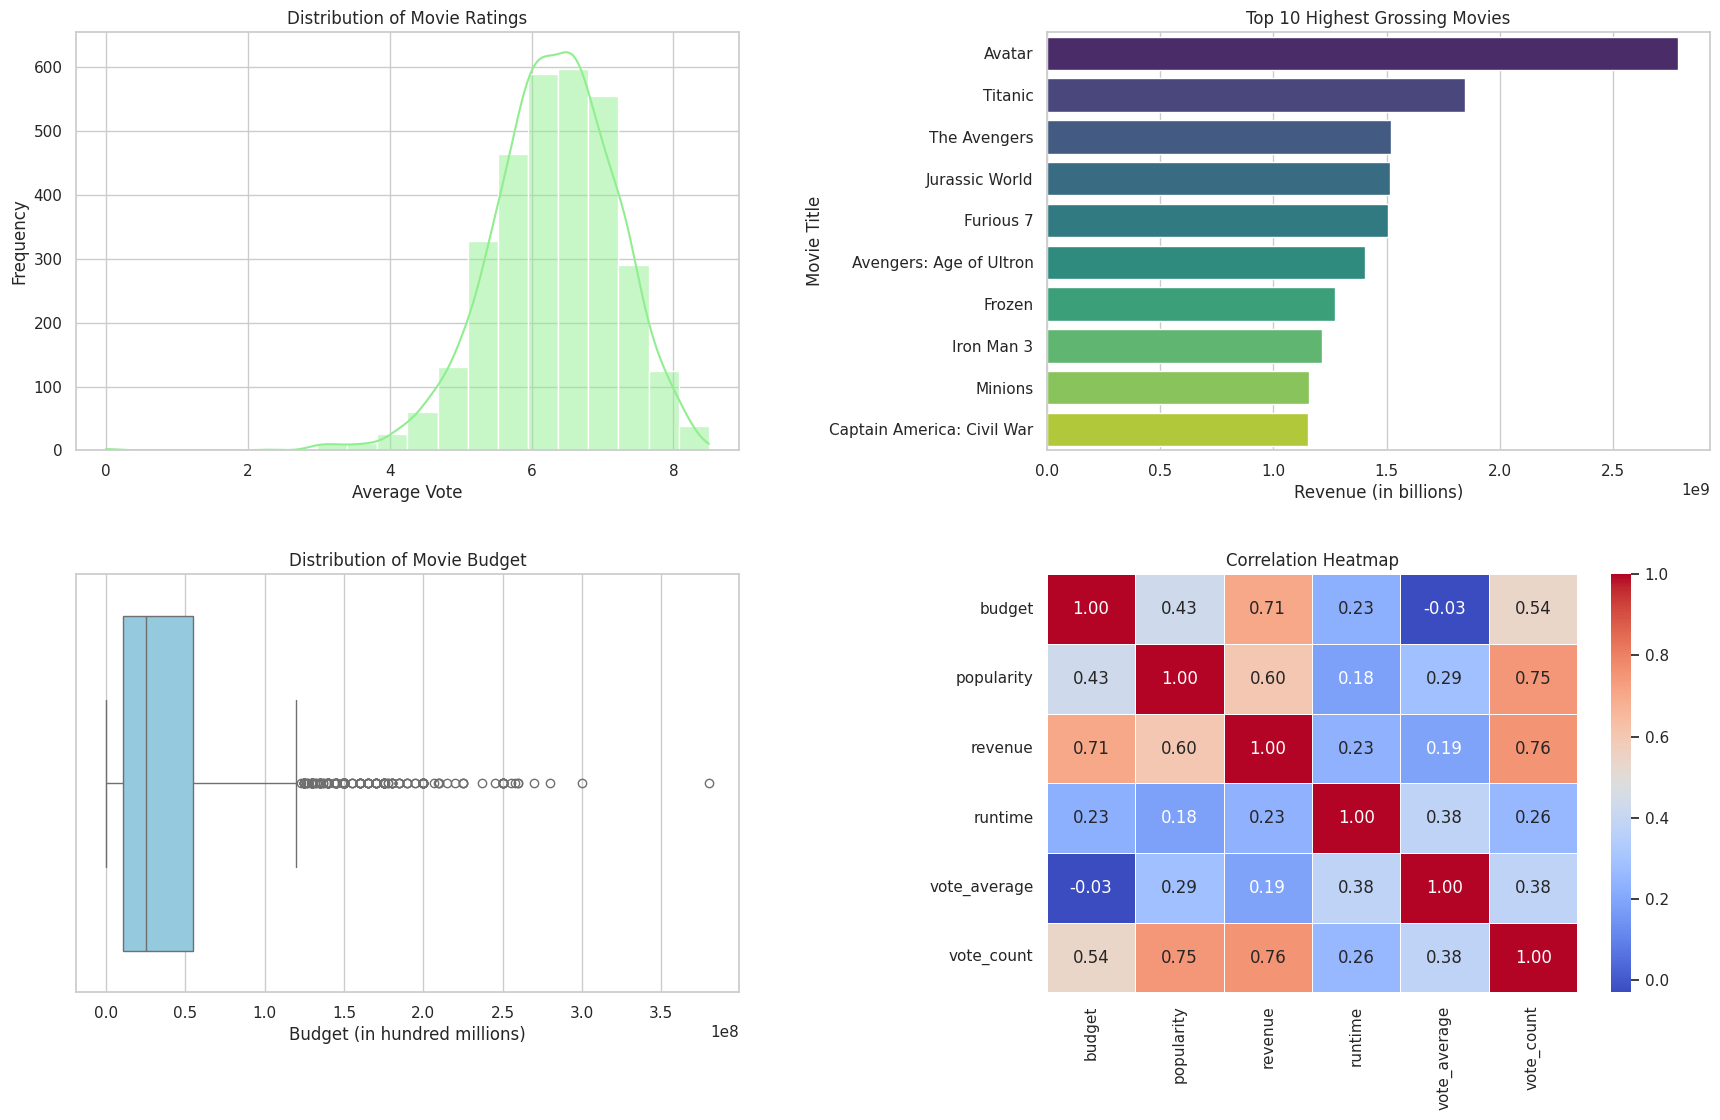

In [64]:
# Set the style for our plots
sns.set_theme(style='whitegrid')
plt.figure(figsize=(18,12))

# Histogram: Distribution of movie ratings
plt.subplot(2,2,1)
sns.histplot(df_finances['vote_average'], bins=20, kde=True, color='lightgreen')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Average Vote')
plt.ylabel('Frequency')

# Barchart: Top 10 movies by revenue
plt.subplot(2,2,2)
top_10_revenue = df_finances.sort_values(by='revenue', ascending=False).head(10)
sns.barplot(x='revenue', y='title', data=top_10_revenue, palette='viridis')
plt.title('Top 10 Highest Grossing Movies')
plt.xlabel('Revenue (in billions)')
plt.ylabel('Movie Title')

# Boxplot: Budget distibution
plt.subplot(2,2,3)
sns.boxplot(x=df_finances['budget'], color='skyblue')
plt.title('Distribution of Movie Budget')
plt.xlabel('Budget (in hundred millions)')

# Correlation Heatmap: Relationship between numerical variables
plt.subplot(2,2,4)
numerical_cols = ['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count']
corr_matrix = df_finances[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')

# Adjust layout and display
plt.tight_layout(pad=3.0, w_pad=4.0, h_pad=3.0)
plt.show()

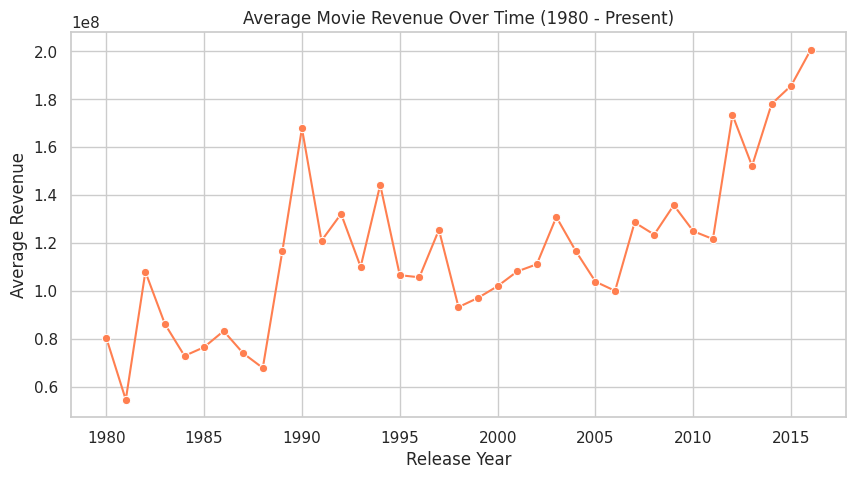

In [65]:
# Line Chart: Trend analysis over time
df_finances['release_year'] = df_finances['release_date'].dt.year
plt.figure(figsize=(10,5))
yearly_revenue = df_finances.groupby('release_year')['revenue'].mean().reset_index()
yearly_revenue = yearly_revenue[yearly_revenue['release_year'] >= 1980]
sns.lineplot(x='release_year', y='revenue', data=yearly_revenue, marker='o', color='coral')
plt.title('Average Movie Revenue Over Time (1980 - Present)')
plt.xlabel('Release Year')
plt.ylabel('Average Revenue')
plt.show()